# Лабораторная работа №3
## Моделирование на ЭВМ байесовского классификатора гауссовских случайных векторов

**Цель работы:** Разработать, реализовать на ЭВМ и исследовать цифровые модели обобщенного байесовского классификатора гауссовских случайных векторов при двух уровнях априорной информации:
1. Полная априорная информация (все вероятностные характеристики известны).
2. Априорная неопределенность (характеристики неизвестны, но есть обучающая выборка).

В этой работе я буду использовать матрицу потерь 0/1 (формула 1.2), что означает, что минимизация среднего риска эквивалентна минимизации вероятности ошибки. 
Для классификации я перейду к натуральному логарифму в решающем правиле (согласно Указанию 1), что позволит заменить вычисление экспонент на сложение логарифмов и квадратичных форм (дискриминантных функций).

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Настраиваю внешний вид графиков для лучшей читаемости
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['axes.grid'] = True

### 1. Реализация базовых функций и классификатора

Здесь я определяю функции для генерации данных и сам класс классификатора. 

Я реализую дискриминантную функцию $g_i(x)$ на основе формулы (1.6) с учетом перехода к логарифму:
$g_i(x) = \ln(\pi_i) - \frac{1}{2}\ln(|\Sigma_i|) - \frac{1}{2}(x - \mu_i)^T \Sigma_i^{-1} (x - \mu_i)$

Множитель $-\frac{N}{2}\ln(2\pi)$ я отбрасываю, так как он одинаков для всех классов и не влияет на поиск максимума.

Также я реализую метод для оценки параметров $(\hat{\pi}_i, \hat{\mu}_i, \hat{\Sigma}_i)$ по обучающей выборке методом максимального правдоподобия (формулы 1.7 и 1.8).

In [59]:
def generate_data(M_list, means, covs):
    """
    Генерирую выборку гауссовских векторов.
    M_list: список количеств элементов для каждого класса
    """
    X = []
    y =[]
    for i, (M, mean, cov) in enumerate(zip(M_list, means, covs)):
        # Генерирую M случайных векторов для класса i
        X_class = np.random.multivariate_normal(mean, cov, M)
        X.append(X_class)
        y.append(np.full(M, i))
    return np.vstack(X), np.concatenate(y)

class BayesClassifier:
    def __init__(self, means=None, covs=None, priors=None):
        """
        Инициализация. Если параметры переданы - это классификатор d0(x) (полная информация).
        Если нет - параметры будут оценены в методе fit() - это d(x, A).
        """
        self.means = np.array(means) if means is not None else None
        self.covs = np.array(covs) if covs is not None else None
        self.priors = np.array(priors) if priors is not None else None
        self.num_classes = len(priors) if priors is not None else None

    def fit(self, X, y, num_classes):
        """
        Обучение классификатора: оценка параметров по формулам (1.7) и (1.8).
        """
        self.num_classes = num_classes
        self.means = []
        self.covs =[]
        self.priors =[]
        
        M_total = len(y)
        for i in range(num_classes):
            X_i = X[y == i]
            M_i = len(X_i)
            
            # Оценка априорной вероятности (1.7)
            self.priors.append(M_i / M_total)
            
            # Оценка матожидания (1.7)
            mean_i = np.mean(X_i, axis=0)
            self.means.append(mean_i)
            
            # Оценка ковариационной матрицы (1.8). 
            # Использую bias=True, чтобы делить на M_i, а не на M_i - 1, как в формуле.
            cov_i = np.cov(X_i, rowvar=False, bias=True)
            self.covs.append(cov_i)
            
        self.means = np.array(self.means)
        self.covs = np.array(self.covs)
        self.priors = np.array(self.priors)

    def predict(self, X):
        """
        Классификация выборки X.
        """
        scores = np.zeros((X.shape[0], self.num_classes))
        
        for i in range(self.num_classes):
            inv_cov = np.linalg.inv(self.covs[i])
            det_cov = np.linalg.det(self.covs[i])
            diff = X - self.means[i]
            
            # Вычисляю квадратичную форму (x - mu)^T * Sigma^-1 * (x - mu) для всех x сразу
            mahalanobis_term = np.sum(diff @ inv_cov * diff, axis=1)
            
            # Логарифмическая дискриминантная функция (без константы 2pi)
            scores[:, i] = np.log(self.priors[i]) - 0.5 * np.log(det_cov) - 0.5 * mahalanobis_term
            
        # Возвращаю индекс класса с максимальным значением функции (формула 1.6)
        return np.argmax(scores, axis=1)

def calculate_error_rate(y_true, y_pred):
    """Вычисляет эмпирическую вероятность ошибки (формулы 1.9, 1.10)"""
    return np.mean(y_true != y_pred)

### 2. Функции для визуализации (Указание 2)

Чтобы выполнить второе указание, я пишу функцию, которая будет рисовать:
а) Эллипсоиды рассеяния (я использую линии уровня плотности распределения).
б) Разделяющие кривые (границы решений) для идеального классификатора $d_0(x)$ и обученного $d(x, A)$.
в) Ошибочно классифицированные реализации (выделяю их красными крестиками).

In [60]:
def plot_classification_results(X_train, y_train, X_test, y_test, clf_true, clf_emp, title=""):
    """
    Функция для комплексной визуализации результатов классификации двумерных данных.
    """
    x_min, x_max = min(X_train[:, 0].min(), X_test[:, 0].min()) - 1, max(X_train[:, 0].max(), X_test[:, 0].max()) + 1
    y_min, y_max = min(X_train[:, 1].min(), X_test[:, 1].min()) - 1, max(X_train[:, 1].max(), X_test[:, 1].max()) + 1
    
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]

    # Предсказания для сетки, чтобы нарисовать границы
    Z_true = clf_true.predict(grid).reshape(xx.shape)
    Z_emp = clf_emp.predict(grid).reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(12, 10))
    
    # б) Разделяющие кривые
    # Граница идеального классификатора (черный пунктир)
    ax.contour(xx, yy, Z_true, levels=[0.5], colors='k', linestyles='--', linewidths=2)
    # Граница обученного классификатора (сплошная синяя линия)
    ax.contour(xx, yy, Z_emp, levels=[0.5], colors='b', linestyles='-', linewidths=2)
    
    colors = ['#FFAAAA', '#AAFFAA', '#AAAAFF', '#FFFFAA']
    markers = ['o', 's', '^', 'D']

    # а) Эллипсоиды рассеяния (линии уровня истинных распределений)
    for i in range(clf_true.num_classes):
        rv = multivariate_normal(clf_true.means[i], clf_true.covs[i])
        ax.contour(xx, yy, rv.pdf(grid).reshape(xx.shape), levels=3, colors='gray', alpha=0.5)

    # Отрисовка тестовой выборки
    for i in range(clf_true.num_classes):
        idx = y_test == i
        ax.scatter(X_test[idx, 0], X_test[idx, 1], c=colors[i], edgecolors='k', 
                   marker=markers[i], s=60, label=f'Класс {i+1} (тест)')

    # в) Выделение ошибочно классифицированных реализаций (крестиками)
    y_pred = clf_emp.predict(X_test)
    errors = y_test != y_pred
    ax.scatter(X_test[errors, 0], X_test[errors, 1], c='red', marker='x', s=100, linewidths=2, label='Ошибки d(x, A)')

    ax.set_title(title)
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    
    # Добавляем пояснения линий в легенду вручную
    ax.plot([],[], 'k--', linewidth=2, label='Граница d0(x)')
    ax.plot([],[], 'b-', linewidth=2, label='Граница d(x, A)')
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    
    plt.tight_layout()
    plt.show()

### 3. Первоначальный перечень экспериментов: Эксперимент 1

**Параметры:** $N=2$ (двумерное пространство), $L=2$ (два класса), $\pi_1 = \pi_2 = 0.5$ (равновероятные классы).
Объемы выборок $M_i = M'_i = 20$.
Математические ожидания: $\mu_1 = (-1, -1)^T, \mu_2 = (1, 1)^T$.

Я поочередно проведу 3 под-эксперимента (а, б, в) с разными матрицами ковариации. Для каждого я:
1. Создам идеальный классификатор $d_0(x)$.
2. Сгенерирую обучающую ($A$) и тестовую ($A'$) выборки.
3. Обучу эмпирический классификатор $d(x, A)$.
4. Выведу вероятности ошибок и построю графики (согласно Указанию 2).

--- Случай 'а': Одинаковые единичные матрицы ковариации ---
Эмпирическая ошибка идеального d0(x): 0.075
Эмпирическая ошибка обученного d(x, A): 0.050


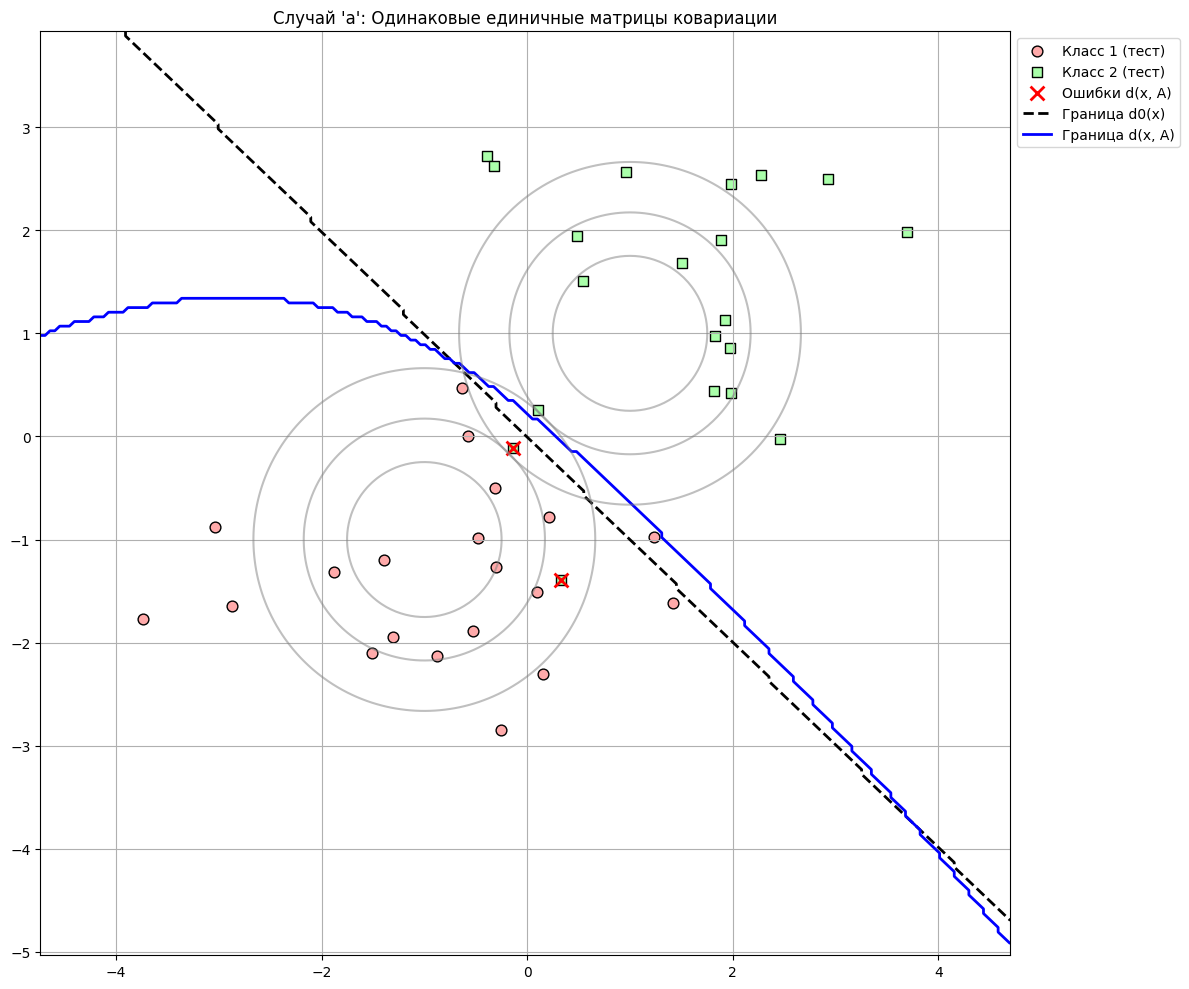

--- Случай 'б': Разные диагональные матрицы ковариации ---
Эмпирическая ошибка идеального d0(x): 0.075
Эмпирическая ошибка обученного d(x, A): 0.050


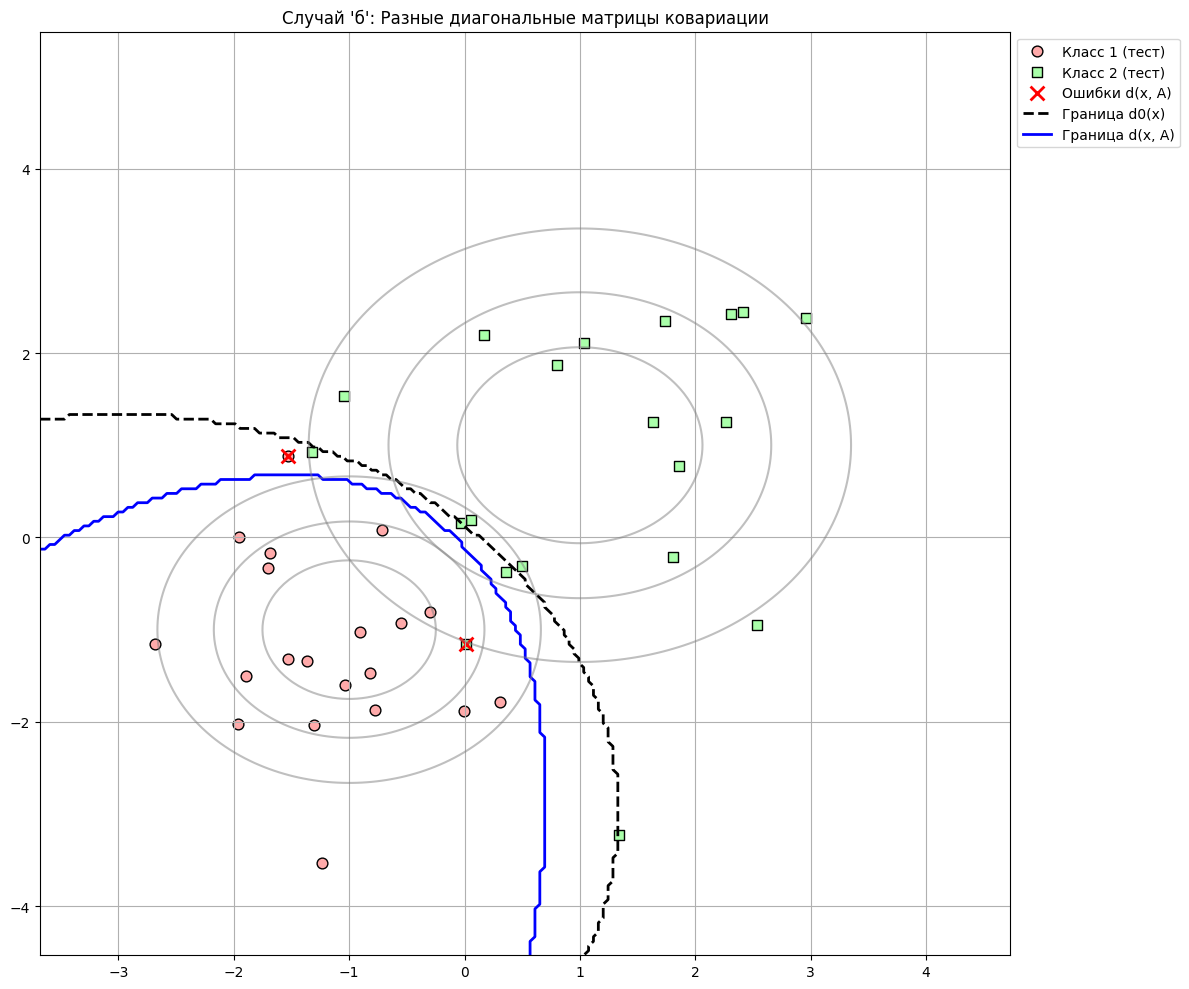

--- Случай 'в': Разные недиагональные матрицы ковариации ---
Эмпирическая ошибка идеального d0(x): 0.050
Эмпирическая ошибка обученного d(x, A): 0.075


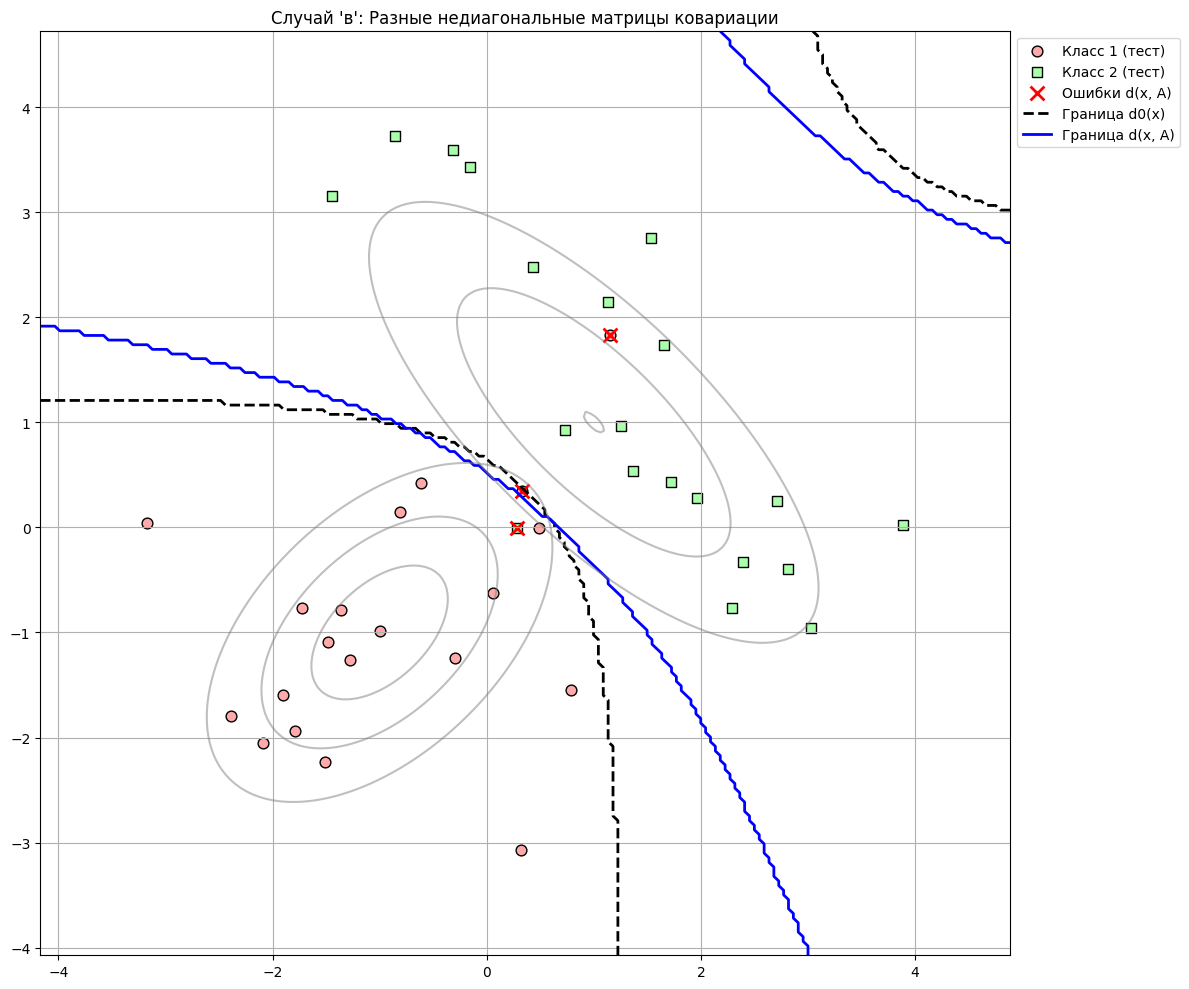

In [61]:
# Общие параметры для Эксперимента 1
N = 2
L = 2
priors_1 = [0.5, 0.5]
M_train_1 = [20, 20]
M_test_1 = [20, 20]
means_1 = [[-1, -1], [1, 1]]

# Варианты матриц ковариации (а, б, в)
covs_1a = [[[1, 0], [0, 1]], [[1, 0], [0, 1]]]
covs_1b = [[[1, 0], [0, 1]], [[2, 0],[0, 2]]]
covs_1c = [[[1, 0.5],[0.5, 1]], [[2, -1.5], [-1.5, 2]]]

experiments =[
    ("Случай 'а': Одинаковые единичные матрицы ковариации", covs_1a),
    ("Случай 'б': Разные диагональные матрицы ковариации", covs_1b),
    ("Случай 'в': Разные недиагональные матрицы ковариации", covs_1c)
]

for title, covs in experiments:
    print(f"--- {title} ---")
    
    # 1. Идеальный классификатор (d0)
    clf_true = BayesClassifier(means=means_1, covs=covs, priors=priors_1)
    
    # 2. Генерация данных
    X_train, y_train = generate_data(M_train_1, means_1, covs)
    X_test, y_test = generate_data(M_test_1, means_1, covs)
    
    # 3. Обучение эмпирического классификатора (d(x, A))
    clf_emp = BayesClassifier()
    clf_emp.fit(X_train, y_train, num_classes=L)
    
    # Оценка ошибок на тестовой выборке
    err_true = calculate_error_rate(y_test, clf_true.predict(X_test))
    err_emp = calculate_error_rate(y_test, clf_emp.predict(X_test))
    
    print(f"Эмпирическая ошибка идеального d0(x): {err_true:.3f}")
    print(f"Эмпирическая ошибка обученного d(x, A): {err_emp:.3f}")
    
    # 4. Визуализация
    plot_classification_results(X_train, y_train, X_test, y_test, clf_true, clf_emp, title=title)

### 4. Оценка безусловных вероятностей ошибки (K-кратное повторение)

В методике выполнения задания (формула 1.11) сказано, что оценки безусловных (средних по всем возможным выборкам $A$) вероятностей ошибки получаются при $K$-кратном повторении процесса обучения и экзамена.

Здесь я пишу функцию для проведения $K=20$ независимых испытаний и усредняю полученные ошибки. Это позволит получить статистически более точную оценку качества классификаторов. Я проведу этот тест для Эксперимента 1 (все три случая) и для Эксперимента 2.

In [62]:
def run_k_experiments(K, L, M_train_list, M_test_list, means, covs, priors):
    """
    Проводит K независимых циклов генерации->обучения->тестирования.
    Возвращает усредненные ошибки для d0(x) и d(x, A).
    """
    err_true_total = 0
    err_emp_total = 0
    
    # Идеальный классификатор создаем один раз, так как его параметры известны
    clf_true = BayesClassifier(means=means, covs=covs, priors=priors)
    
    for k in range(K):
        # Генерирую новые обучающую и экзаменационную выборки
        X_train, y_train = generate_data(M_train_list, means, covs)
        X_test, y_test = generate_data(M_test_list, means, covs)
        
        # Обучаю новый классификатор на новой выборке A
        clf_emp = BayesClassifier()
        clf_emp.fit(X_train, y_train, num_classes=L)
        
        # Тестирую оба классификатора на независимой выборке A'
        err_true_total += calculate_error_rate(y_test, clf_true.predict(X_test))
        err_emp_total += calculate_error_rate(y_test, clf_emp.predict(X_test))
        
    # Усредняю по K экспериментам (формула 1.11)
    return err_true_total / K, err_emp_total / K

In [63]:
K_repeats = 20

print("=== Результаты K-кратного (K=20) повторения для Эксперимента 1 ===")
for title, covs in experiments:
    avg_err_true, avg_err_emp = run_k_experiments(
        K=K_repeats, L=2, 
        M_train_list=M_train_1, M_test_list=M_test_1, 
        means=means_1, covs=covs, priors=priors_1
    )
    print(f"{title}:")
    print(f"  Средняя ошибка d0(x)   = {avg_err_true:.4f}")
    print(f"  Средняя ошибка d(x, A) = {avg_err_emp:.4f}\n")

=== Результаты K-кратного (K=20) повторения для Эксперимента 1 ===
Случай 'а': Одинаковые единичные матрицы ковариации:
  Средняя ошибка d0(x)   = 0.0712
  Средняя ошибка d(x, A) = 0.0762

Случай 'б': Разные диагональные матрицы ковариации:
  Средняя ошибка d0(x)   = 0.1150
  Средняя ошибка d(x, A) = 0.1237

Случай 'в': Разные недиагональные матрицы ковариации:
  Средняя ошибка d0(x)   = 0.0575
  Средняя ошибка d(x, A) = 0.0662



### 5. Эксперимент 2 (4 класса)

**Параметры:** $N=2$, $L=4$ (четыре класса), $\pi_i = 0.25$ для $i=\overline{1,4}$.
Объемы выборок $M_i = M'_i = 20$. Количество повторений $K=20$.

Заданы 4 различных вектора математического ожидания и 4 разные ковариационные матрицы.
Я выполню $K$-кратный прогон эксперимента для оценки средних вероятностей ошибок.

In [64]:
# Параметры для Эксперимента 2
L_2 = 4
priors_2 =[0.25, 0.25, 0.25, 0.25]
M_train_2 = [20, 20, 20, 20]
M_test_2 =[20, 20, 20, 20]

means_2 = [[-1, -1],
    [-1, 1],
    [1, 1],[1, -1]
]

covs_2 = [
    [[1, 0],[0, 1]],
    [[1, 0.5], [0.5, 1]],
    [[2, 0], [0, 2]],
    [[1, -0.5],[-0.5, 1]]
]

print("=== Результаты K-кратного (K=20) повторения для Эксперимента 2 (4 класса) ===")
avg_err_true_4, avg_err_emp_4 = run_k_experiments(
    K=K_repeats, L=L_2, 
    M_train_list=M_train_2, M_test_list=M_test_2, 
    means=means_2, covs=covs_2, priors=priors_2
)

print(f"Средняя ошибка идеального классификатора d0(x)   = {avg_err_true_4:.4f}")
print(f"Средняя ошибка обученного классификатора d(x, A) = {avg_err_emp_4:.4f}")

=== Результаты K-кратного (K=20) повторения для Эксперимента 2 (4 класса) ===
Средняя ошибка идеального классификатора d0(x)   = 0.2913
Средняя ошибка обученного классификатора d(x, A) = 0.2988


### 6. Краткие выводы

Выполнив моделирование, я убедился в следующем:
1. Идеальный байесовский классификатор $d_0(x)$ (построенный при полной информации) задает нижнюю теоретическую границу ошибки (минимальный средний риск). 
2. Классификатор $d(x, A)$, который обучается на конечной выборке (оценивая параметры методом максимального правдоподобия), всегда в среднем показывает большую вероятность ошибки по сравнению с $d_0(x)$. Это вызвано статистической погрешностью оценки параметров $\hat{\mu}$ и $\hat{\Sigma}$ при малом объеме обучающей выборки (в нашем случае $M_i = 20$).
3. Графики наглядно показывают, как разделяющая граница обученного классификатора $d(x, A)$ (синяя линия) "дрожит" и отклоняется от оптимальной границы $d_0(x)$ (черный пунктир) из-за случайного характера обучающей выборки.
4. В случаях, когда матрицы ковариации классов отличаются (случаи 1б и 1в), разделяющие границы становятся нелинейными (квадратичными параболами, гиперболами или эллипсами), что математически следует из разности квадратичных форм в логарифмической дискриминантной функции. При равных матрицах (случай 1а) квадратичные члены сокращаются, и граница становится прямой линией.